# D-SUP-02 — shallow L1 functional-entry recoverability

| 항목 | 값 |
|---|---|
| **research_question** | RQ-D14 에서 `CORPORATE_OR_APP_LANDING`/`UNDETERMINED` 로 분류된 target 에서, frozen DOM/AX evidence 만으로 shallow L1 functional-entry candidate 가 관측되는가 |
| **inquiry_kind** | `DIRECTOR_SUPPLEMENTAL` (기존 D research queue 와 별개, 기존 RQ 를 바꾸지 않음) |
| **hypothesis_id** | `H-SUP02-L1-RECOVERABILITY` |
| **competing** | H1 대부분 회복가능 / H2 대부분 출구 없음 / H3 evidence 로 판정 불가 |
| **grain** | target (`wtg`) |
| **n** | 56 (대상 29 = CORPORATE 3 + UNDETERMINED 26 · 대조 27 = FUNCTIONAL_LANDING) |
| **seed** | 20260827 |
| **MLflow run_id** | `658526a810ed4b15ac15306fa6d16eaf` (experiment `LA_01_FRAME`) |
| **rule version** | `DSUP02_L1_v1` (primary) · `DSUP02_L1_v1b` (POST_HOC 민감도) |

### input snapshot sha256
| 입력 | sha256 |
|---|---|
| `results/RQ_D14_frame_validity.json` | `ee4cc0e989ba72ed615293d51f41575e4308360e30bb4338eadfebcc2e739966` |
| `results/D_OBSERVATION_TABLE_v2.csv` | `c39c10f09f7a6a7603409550eb331612eb44634eb98ec387a604aa5221351e6b` |

### code / result sha256
| 파일 | sha256 |
|---|---|
| `tools/dsup02_l1_recoverability.py` | `fbc05263a2da5934ba9d518df22b3752337f15859265df1d91766f4473cd14a3` |
| `results/DSUP02_l1_recoverability.json` | `dedd7c0087f042f26cdba105570d93df68c2963f756de2a5ef676293130b7f3d` |

> **firewall**: holdout label · `LABEL_SPLIT_FROZEN*` · `HOLDOUT_FOR_C*` · `RAW_L1~L4*` ·
> `PACKET_L*` · `*_OVERLAP*` · `PRECEDENCE_CONTESTED*` · `CALIBRATION_FOR_B*` · `**/control/**` 는
> **열지 않았다**. live navigation 없음 · REAL_TARGET 접속 없음 · 어떤 후보도 클릭하지 않았다.


In [1]:
import json, sys
from pathlib import Path
import pandas as pd

RD = Path("/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research"
          "/research/landing_accessibility/research_d")
sys.path.insert(0, str(RD / "tools"))

DOC = json.loads((RD / "results/DSUP02_l1_recoverability.json").read_text(encoding="utf-8"))
R = DOC["results"]
print("verdict :", DOC["verdict"])
print("n       :", DOC["n_observed"], "/", DOC["n_expected"])
print("strata  :", DOC["strata"])
print("missing :", DOC["missing"])

verdict : SUPPORTED
n       : 56 / 56
strata  : {'target_classes': ['CORPORATE_OR_APP_LANDING', 'UNDETERMINED'], 'control_class': 'FUNCTIONAL_LANDING', 'n_target': 29, 'n_control': 27}
missing : {'n_missing_targets': 0, 'probe_absent': ['64d30ef262d8782d', 'ef06dc942ef3ccc9'], 'dom_parse_fail': []}


## 1. 후보 조작화 정의 (전문) — SSOT v2.1 §5 Region 정의에서 유도

In [2]:
print(DOC["definitions"]["candidate"])


=== shallow L1 functional-entry candidate — 조작화 정의 (전문) ===

[유도 근거] SSOTV2/01_REPRESENTATIVE_FUNCTION_MAPPING_DT_v2.1.md §5 Stage 3 branch tree 는
7개 archetype 각각에 대해 **Region** 을 다음과 같이 정의한다 (원문 요지):

  Q QUERY                : "검색 입력 control 이 사용 가능한 상태로 노출"
  C CONTENT_OPEN         : "content card/link list 가 노출"
  I ITEM_DETAIL          : "individual item/product card or link list"
  P PLACE_LOOKUP         : "place search control 또는 place list"
  M COMMUNICATION_ENTRY  : "thread/post list 또는 compose-entry control"
  F FINANCIAL_ACTION_ENTRY: "balance/transfer/payment/auth function entry control"
  U UTILITY_ENTRY        : "function surface entry control"

즉 SSOT 에서 Region 은 **기능 면(surface) 또는 그 면을 여는 entry control** 이다.
D-SUP-02 는 이 7개 Region 정의의 **합집합(union)** 을 archetype 을 특정하지 않은 채 쓴다.

[정의] target T 의 frozen L0-A evidence 안에서 관측된 어떤 노드 x 가 아래 (a)·(b)·(c) 를
모두 만족하면 x 는 T 의 **shallow L1 functional-entry candidate** 다.

  (a) FORM — x 는 다음 중 하나다.
      (a1) 이동형 링크: <a href> 이거나 A

## 2. 제외규칙 (전문)

In [3]:
print(DOC["definitions"]["exclusions"])


=== EXCLUSION RULES (전문) ===
아래 규칙은 **어휘 매칭보다 먼저** 적용된다 (예: "뉴스룸" 은 E4 에 걸리므로 C 어휘 "뉴스" 로
승격되지 않는다). 규칙은 결과를 보기 전에 고정되었고 결과를 본 뒤 수정하지 않았다.

E1 APP_INSTALL — 앱 설치/스토어 이동
    표면어: 앱 다운로드, 앱다운로드, 앱설치, 앱 설치, 앱으로 보기, 앱에서 보기, 앱으로보기,
            앱 열기, 앱열기, 앱에서 열기, 앱으로 이동, 앱 실행, app store, google play,
            play 스토어, 플레이스토어, 원스토어, 갤럭시 스토어, 갤럭시스토어, appstore,
            download the app, get the app
    host  : play.google.com, apps.apple.com, itunes.apple.com, onelink.me, app.link,
            appsflyer.com, adjust.com, onestore.co.kr, galaxystore.samsung.com, applink

E2 EXTERNAL_SNS — 외부 소셜/공유
    표면어: 페이스북, 인스타그램, 인스타, 유튜브, 트위터, 카카오스토리, 카카오채널,
            카카오톡 채널, 네이버 밴드, 밴드, 링크드인, 틱톡, 구글플러스, 공유하기, 공유,
            url 복사, 링크 복사, sns, facebook, instagram, twitter, youtube, tiktok,
            linkedin, threads, share
    host  : facebook.com, instagram.com, twitter.com, x.com, youtube.com, youtu.be,
            tiktok.com, linkedin.com, threads.net, band.us, pf.kakao.com, story.kakao

## 3. 3값 판정규칙 (전문 · 사전 고정)

In [4]:
print(DOC["definitions"]["verdict_rule"])


=== 3값 판정 규칙 (사전 고정 — 결과를 본 뒤 바꾸지 않았다) ===

입력: target 당 후보 개수 n_cand (E1~E9 통과, dedup 후), evidence 가용성 플래그.

R0  evidence 부재 : dom.html · ax.json · probe.json 이 **모두** 없으면 → AMBIGUOUS
                    (reason = EVIDENCE_ABSENT)
R1  퇴화 캡처     : D 가 확인한 퇴화 관측 (computed_css 3 bytes AND dom_body_empty==1) 이면
                    후보 개수와 무관하게 → AMBIGUOUS (reason = DEGENERATE_CAPTURE)
                    ※ 이 규칙을 끈 "퇴화 포함" 버전을 반드시 병기한다 (R1 만 무력화).
R2  후보 ≥ 1      : → RECOVERABLE_WITHIN_L1
R3  후보 == 0     : → NO_FUNCTIONAL_EXIT_OBSERVED

우선순위: R0 > R1 > R2 > R3.

사전 고정 민감도 임계 (primary 는 R2 의 ≥1 이다. 아래는 보고용이며 primary 를 대체하지 않는다):
  S1  n_cand >= 3
  S2  n_cand_visible_hittable >= 1
      (probe primary_action_candidates 중 viewport_visible==true AND hittable==true 인 후보)
  S3  WEAK(E9 auth) 후보를 primary 에 포함시켰을 때의 n_cand >= 1



## 4. 3값 결과 — 29건 기준 · 56건 기준 · 퇴화 포함/제외 병기

**대조군 없이 대상군 비율만 읽지 마라.** 아래 표는 항상 대조군을 같이 보여준다.

In [5]:
def tally_df(blk, label):
    rows = []
    for v in ("RECOVERABLE_WITHIN_L1", "NO_FUNCTIONAL_EXIT_OBSERVED", "AMBIGUOUS"):
        c = blk[v]
        rows.append({"scope": label, "n": blk["n"], "verdict": v, "k": c["k"],
                     "rate": c["rate"],
                     "wilson95": f'[{c["wilson95"][0]}, {c["wilson95"][1]}]'})
    return pd.DataFrame(rows)

prim = R["primary_degenerate_isolated"]
df_primary = pd.concat([tally_df(prim["target_29"], "대상 29 (CORP+UNDET)"),
                        tally_df(prim["control_27"], "대조 27 (FUNCTIONAL)"),
                        tally_df(prim["all_56"], "전체 56")], ignore_index=True)
df_primary

,scope,n,verdict,k,rate,wilson95
0,대상 29 (CORP+UNDET),29,RECOVERABLE_WITHIN_L1,24,0.8276,"[0.6545, 0.924]"
1,대상 29 (CORP+UNDET),29,NO_FUNCTIONAL_EXIT_OBSERVED,3,0.1034,"[0.0358, 0.2639]"
2,대상 29 (CORP+UNDET),29,AMBIGUOUS,2,0.0690,"[0.0191, 0.2196]"
3,대조 27 (FUNCTIONAL),27,RECOVERABLE_WITHIN_L1,25,0.9259,"[0.7663, 0.9794]"
4,대조 27 (FUNCTIONAL),27,NO_FUNCTIONAL_EXIT_OBSERVED,0,0.0000,"[0.0, 0.1246]"
5,대조 27 (FUNCTIONAL),27,AMBIGUOUS,2,0.0741,"[0.0206, 0.2337]"
6,전체 56,56,RECOVERABLE_WITHIN_L1,49,0.8750,"[0.7637, 0.9381]"
7,전체 56,56,NO_FUNCTIONAL_EXIT_OBSERVED,3,0.0536,"[0.0184, 0.1461]"
8,전체 56,56,AMBIGUOUS,4,0.0714,"[0.0281, 0.1698]"


In [6]:
incl = R["degenerate_included"]
df_deg = pd.concat([tally_df(prim["target_29"], "대상29 · 퇴화격리(primary)"),
                    tally_df(incl["target_29"], "대상29 · 퇴화포함"),
                    tally_df(prim["control_27"], "대조27 · 퇴화격리(primary)"),
                    tally_df(incl["control_27"], "대조27 · 퇴화포함")], ignore_index=True)
df_deg

,scope,n,verdict,k,rate,wilson95
0,대상29 · 퇴화격리(primary),29,RECOVERABLE_WITHIN_L1,24,0.8276,"[0.6545, 0.924]"
1,대상29 · 퇴화격리(primary),29,NO_FUNCTIONAL_EXIT_OBSERVED,3,0.1034,"[0.0358, 0.2639]"
2,대상29 · 퇴화격리(primary),29,AMBIGUOUS,2,0.0690,"[0.0191, 0.2196]"
3,대상29 · 퇴화포함,29,RECOVERABLE_WITHIN_L1,26,0.8966,"[0.7361, 0.9642]"
4,대상29 · 퇴화포함,29,NO_FUNCTIONAL_EXIT_OBSERVED,3,0.1034,"[0.0358, 0.2639]"
5,대상29 · 퇴화포함,29,AMBIGUOUS,0,0.0000,"[0.0, 0.117]"
6,대조27 · 퇴화격리(primary),27,RECOVERABLE_WITHIN_L1,25,0.9259,"[0.7663, 0.9794]"
7,대조27 · 퇴화격리(primary),27,NO_FUNCTIONAL_EXIT_OBSERVED,0,0.0000,"[0.0, 0.1246]"
8,대조27 · 퇴화격리(primary),27,AMBIGUOUS,2,0.0741,"[0.0206, 0.2337]"
9,대조27 · 퇴화포함,27,RECOVERABLE_WITHIN_L1,25,0.9259,"[0.7663, 0.9794]"


In [7]:
# stratum 별. CORPORATE_OR_APP_LANDING 은 n=3 — Wilson CI 폭 56%p, 과해석 금지.
pd.concat([tally_df(b, c) for c, b in prim["by_identity_class"].items()], ignore_index=True)

,scope,n,verdict,k,rate,wilson95
0,CORPORATE_OR_APP_LANDING,3,RECOVERABLE_WITHIN_L1,3,1.0000,"[0.4385, 1.0]"
1,CORPORATE_OR_APP_LANDING,3,NO_FUNCTIONAL_EXIT_OBSERVED,0,0.0000,"[0.0, 0.5615]"
2,CORPORATE_OR_APP_LANDING,3,AMBIGUOUS,0,0.0000,"[0.0, 0.5615]"
3,FUNCTIONAL_LANDING,27,RECOVERABLE_WITHIN_L1,25,0.9259,"[0.7663, 0.9794]"
4,FUNCTIONAL_LANDING,27,NO_FUNCTIONAL_EXIT_OBSERVED,0,0.0000,"[0.0, 0.1246]"
5,FUNCTIONAL_LANDING,27,AMBIGUOUS,2,0.0741,"[0.0206, 0.2337]"
6,UNDETERMINED,26,RECOVERABLE_WITHIN_L1,21,0.8077,"[0.6212, 0.9149]"
7,UNDETERMINED,26,NO_FUNCTIONAL_EXIT_OBSERVED,3,0.1154,"[0.04, 0.2898]"
8,UNDETERMINED,26,AMBIGUOUS,2,0.0769,"[0.0214, 0.2414]"


## 5. 대조군 대비 — 이 지표는 두 층을 구분하지 못한다

In [8]:
cc = R["control_contrast"]
print(json.dumps(cc, ensure_ascii=False, indent=1))
dist = R["candidate_count_distribution"]
import statistics as st
print("\n후보 개수 중앙값  대상:", st.median(dist["target_29"]),
      " 대조:", st.median(dist["control_27"]))
print("후보 개수 평균    대상:", round(st.mean(dist["target_29"]), 1),
      " 대조:", round(st.mean(dist["control_27"]), 1))
from scipy.stats import mannwhitneyu, fisher_exact
print("Mann-Whitney U (개수):", mannwhitneyu(dist["target_29"], dist["control_27"],
                                            alternative="two-sided"))
t = prim["target_29"]; c = prim["control_27"]
tab = [[t["RECOVERABLE_WITHIN_L1"]["k"], t["NO_FUNCTIONAL_EXIT_OBSERVED"]["k"]],
       [c["RECOVERABLE_WITHIN_L1"]["k"], c["NO_FUNCTIONAL_EXIT_OBSERVED"]["k"]]]
print("Fisher exact (R vs NE, 퇴화 제외):", tab, fisher_exact(tab))

{
 "target_recoverable_rate": 0.8276,
 "control_recoverable_rate": 0.9259,
 "rate_difference": -0.0983,
 "note": "대조군 없이 대상군 비율만 보면 무의미하다. 두 비율의 차이가 판별력이다."
}

후보 개수 중앙값  대상: 30  대조: 73
후보 개수 평균    대상: 38.8  대조: 186.8


Mann-Whitney U (개수): MannwhitneyuResult(statistic=np.float64(246.0), pvalue=np.float64(0.017354352962766568))
Fisher exact (R vs NE, 퇴화 제외): [[24, 3], [25, 0]] SignificanceResult(statistic=np.float64(0.0), pvalue=np.float64(0.23642533936651577))


## 6. 사후 적대적 변형 `DSUP02_L1_v1b` (POST_HOC · primary 대체 아님)

In [9]:
v1b = R["post_hoc_variant_v1b"]
print(v1b["status"]); print(v1b["patch_definition"])
display(pd.concat([tally_df(v1b["target_29"], "v1b 대상 29"),
                   tally_df(v1b["control_27"], "v1b 대조 27")], ignore_index=True))
print("v1 -> v1b 로 뒤집힌 target:")
display(pd.DataFrame(v1b["verdict_flips_vs_v1"]))

POST_HOC_ADVERSARIAL — primary 를 대체하지 않는다

=== POST_HOC ADVERSARIAL VARIANT  DSUP02_L1_v1b (사후 · 전수 적용 · primary 를 대체하지 않음) ===

[왜 만들었나] v1 결과를 낸 뒤, 판정을 좌우하는 **소수후보 target (n_cand<=6)** 을 손으로 감사한
결과 어휘사전 누수 3종이 확인됐다. 전부 후보를 **과대계수** 하는 방향이다.

  L1  쿠키 동의 배너의 컨트롤이 후보로 샜다.
      예: 밴드 '쿠키 설정' -> U_UTILITY:text:설정 / Netflix '설정 저장','쿠키 목록 검색'
  L2  언어·표시설정 combobox 가 (b*) 검색컨트롤 예외로 통과했다.
      예: Instagram '표시 언어 변경' (role=combobox, 어휘 매칭 0인데 통과)
  L3  앱스토어 이동 링크가 I_ITEM 어휘 '스토어' 로 통과했다.
      예: 에이닷 전화 '애플 스토어에서 다운로드'

[v1b 가 v1 과 다른 점 — 이것이 전부다]
  P1  E3 에 쿠키/동의 어휘 추가: 쿠키, 동의, 동의하기, 모두 허용, 모두 수락, 필수만,
      선택 동의, 설정 저장, 쿠키 설정, consent, cookies, accept all, manage cookies,
      preferences
  P2  E6 에 언어/표시설정 어휘 추가: 언어, 표시 언어, 언어 변경, 국가 선택, 지역 설정,
      language, region
  P3  E1 에 앱스토어 표면형 추가: 애플 스토어, 앱스토어, 앱 스토어, 플레이 스토어,
      에서 다운로드, download on the app, get it on google play
  P4  U_UTILITY 어휘에서 '설정' 삭제 (UI 환경설정과 구분되지 않는다)
  P5  I_ITEM 어휘에서 '스토어' 삭제 (path token 'store' 는 유지)
  P6 

,scope,n,verdict,k,rate,wilson95
0,v1b 대상 29,29,RECOVERABLE_WITHIN_L1,22,0.7586,"[0.5789, 0.8778]"
1,v1b 대상 29,29,NO_FUNCTIONAL_EXIT_OBSERVED,5,0.1724,"[0.076, 0.3455]"
2,v1b 대상 29,29,AMBIGUOUS,2,0.0690,"[0.0191, 0.2196]"
3,v1b 대조 27,27,RECOVERABLE_WITHIN_L1,25,0.9259,"[0.7663, 0.9794]"
4,v1b 대조 27,27,NO_FUNCTIONAL_EXIT_OBSERVED,0,0.0000,"[0.0, 0.1246]"
5,v1b 대조 27,27,AMBIGUOUS,2,0.0741,"[0.0206, 0.2337]"


v1 -> v1b 로 뒤집힌 target:


,wtg,service,identity_class,v1,v1b,n_cand_v1,n_cand_v1b
0,65f15ce8fee25b24,밴드,UNDETERMINED,RECOVERABLE_WITHIN_L1,NO_FUNCTIONAL_EXIT_OBSERVED,1,0
1,5ede56738376a8c5,Instagram,UNDETERMINED,RECOVERABLE_WITHIN_L1,NO_FUNCTIONAL_EXIT_OBSERVED,1,0


In [10]:
print(json.dumps(R["hand_audit_of_marginal_targets"], ensure_ascii=False, indent=1))

{
 "scope": "v1 결과에서 n_cand<=6 인 target 을 전수 손 감사했다 (사후).",
 "leaks_found": [
  "쿠키동의 컨트롤(밴드·Netflix)",
  "언어선택 combobox(Instagram)",
  "앱스토어 링크의 '스토어' 어휘(에이닷 전화)"
 ],
 "direction": "확인된 누수는 모두 후보를 과대계수하는 방향이었다.",
 "near_misses_false_negative": [
  "컴포즈커피 '브랜드 홈페이지'(/index1) — 기능면 진입일 수 있으나 기능어휘가 없어 탈락",
  "모니모 '공동인증서' — SSOT F-Region 의 auth entry 로 볼 여지가 있으나 어휘 미등재로 탈락"
 ],
 "note": "즉 v1 은 위양성(과대)과 위음성(과소)을 모두 갖는다. 방향은 상쇄적이며 어느 쪽도 0으로 가정하지 않는다."
}


## 7. slot 별 후보 출처 — 어느 slot 이 후보를 냈나

In [11]:
sp = R["slot_provenance"]
print("target-level 기여 :", sp["target_level_slot_contributed"], "(분모 56)")
print("probe 전용 target :", sp["targets_with_probe_only_candidates"])
print("dom   전용 target :", sp["targets_with_dom_only_candidates"])
print("\n" + sp["dedup_caveat"])
by = {x["wtg"]: x for x in DOC["per_target"]}
pd.DataFrame([{"wtg": w, "service": by[w]["service"],
               "identity_class": by[w]["identity_class"],
               "n_cand": by[w]["n_candidates"],
               "degenerate": by[w]["degenerate_capture"],
               "dom_body_empty_shell": by[w]["slots_status"]}
              for w in sp["targets_with_probe_only_candidates"]])

target-level 기여 : {'dom': 45, 'probe': 50, 'ax': 42} (분모 56)
probe 전용 target : ['95967b50683649f2', 'fb3d1841dddfd982', 'a215c45b2cc585ca', '5beeafeac2e27eae', '65f15ce8fee25b24']
dom   전용 target : []

cross-slot dedup 은 (표면문자열, href) 로 하는데 같은 노드라도 slot 마다 표면문자열 구성이 달라(probe 는 nearby_heading 을 붙이고 ax 는 computed name 을 쓴다) 병합이 잘 되지 않는다. 따라서 candidate_level_slot_exclusive 는 **상한(과대추정)** 이다. slot 기여 판단은 target_level 지표와 targets_with_probe_only_candidates 로 하라.


,wtg,service,identity_class,n_cand,degenerate,dom_body_empty_shell
0,95967b50683649f2,NH스마트뱅킹,UNDETERMINED,23,True,"{'dom': 'OK', 'ax': 'OK', 'probe': 'OK'}"
1,fb3d1841dddfd982,NH콕뱅크,UNDETERMINED,23,True,"{'dom': 'OK', 'ax': 'OK', 'probe': 'OK'}"
2,a215c45b2cc585ca,에이닷 전화,UNDETERMINED,2,False,"{'dom': 'OK', 'ax': 'OK', 'probe': 'OK'}"
3,5beeafeac2e27eae,TikTok,UNDETERMINED,1,False,"{'dom': 'OK', 'ax': 'OK', 'probe': 'OK'}"
4,65f15ce8fee25b24,밴드,UNDETERMINED,1,False,"{'dom': 'OK', 'ax': 'OK', 'probe': 'OK'}"


## 8. 민감도 (사전 고정 임계)

In [12]:
pd.DataFrame([{"scope": s, "threshold": k, "k": v["k"], "n": v["n"], "rate": v["rate"],
                "wilson95": f'[{v["wilson95"][0]}, {v["wilson95"][1]}]'}
               for s, blk in R["sensitivity"].items() for k, v in blk.items()])

,scope,threshold,k,n,rate,wilson95
0,target_29,S1_ge3,22,29,0.7586,"[0.5789, 0.8778]"
1,target_29,S2_visible_hittable_ge1,12,29,0.4138,"[0.2551, 0.5926]"
2,target_29,S3_with_weak_auth_ge1,26,29,0.8966,"[0.7361, 0.9642]"
3,control_27,S1_ge3,25,27,0.9259,"[0.7663, 0.9794]"
4,control_27,S2_visible_hittable_ge1,14,27,0.5185,"[0.3399, 0.6926]"
5,control_27,S3_with_weak_auth_ge1,25,27,0.9259,"[0.7663, 0.9794]"
6,all_56,S1_ge3,47,56,0.8393,"[0.7219, 0.9131]"
7,all_56,S2_visible_hittable_ge1,26,56,0.4643,"[0.3402, 0.593]"
8,all_56,S3_with_weak_auth_ge1,51,56,0.9107,"[0.8074, 0.9613]"


## 9. target 별 판정과 상위 후보

In [13]:
rows = []
for x in DOC["per_target"]:
    top = x["top_candidates"][0] if x["top_candidates"] else {}
    rows.append({"identity_class": x["identity_class"], "service": x["service"],
                 "prior_archetype": x["prior_archetype"], "n_cand": x["n_candidates"],
                 "verdict": x["verdict"], "reason": x["verdict_reason"],
                 "slots": ",".join(sorted(x["candidate_slot_provenance"])),
                 "top_text": (top.get("text") or "")[:40],
                 "top_href": (top.get("href") or "")[:44],
                 "regions": "/".join(top.get("regions", []))}) 
df_t = pd.DataFrame(rows).sort_values(["identity_class", "n_cand"], ascending=[True, False])
pd.set_option("display.max_rows", 80, "display.width", 240, "display.max_colwidth", 46)
df_t

,identity_class,service,prior_archetype,n_cand,verdict,reason,slots,top_text,top_href,regions
0,CORPORATE_OR_APP_LANDING,카카오T,PLACE_LOOKUP,45,RECOVERABLE_WITHIN_L1,n_cand=45>=1,"ax,dom,probe",선불충전금 현황,,F_FINANCE
1,CORPORATE_OR_APP_LANDING,탑마트,ITEM_DETAIL,44,RECOVERABLE_WITHIN_L1,n_cand=44>=1,"ax,dom,probe",+ 더보기,/shopping/eventBoardList,I_ITEM/U_UTILITY
2,CORPORATE_OR_APP_LANDING,GS25,ITEM_DETAIL,32,RECOVERABLE_WITHIN_L1,n_cand=32>=1,"ax,dom,probe",온라인몰 편의점 결제,,F_FINANCE/I_ITEM
3,FUNCTIONAL_LANDING,롯데마트,ITEM_DETAIL,1160,RECOVERABLE_WITHIN_L1,n_cand=1160>=1,"ax,dom,probe","[사전예약, 9/6~9/10 배송일선택] 엘지 생활의 품격 기프트 3호",/products/OS8809949558397/details,C_CONTENT/I_ITEM/U_UTILITY
4,FUNCTIONAL_LANDING,메가커피,ITEM_DETAIL,839,RECOVERABLE_WITHIN_L1,n_cand=839>=1,"ax,dom,probe",,/goods/goods_search.php?adUrl=https%3A%2F%2F,I_ITEM/Q_QUERY
5,FUNCTIONAL_LANDING,NS홈쇼핑,ITEM_DETAIL,468,RECOVERABLE_WITHIN_L1,n_cand=468>=1,"ax,dom,probe",1정에 94원! 5중 복합 기능성! 광동생활건강 뼈건강엔 칼마디k 아연,/goods/36129658,C_CONTENT/I_ITEM
6,FUNCTIONAL_LANDING,네이버,QUERY,370,RECOVERABLE_WITHIN_L1,n_cand=370>=1,"ax,dom,probe",스타벅스 블랙 글레이즈드 라떼 출시전 먹어본 후기 w.가격 칼로리,https://in.naver.com/rladbrud8791/contents/i,C_CONTENT/I_ITEM/M_COMMUNICATION
7,FUNCTIONAL_LANDING,다음,QUERY,345,RECOVERABLE_WITHIN_L1,n_cand=345>=1,"ax,dom,probe",희상 네팔 대홍수 네팔 대홍수… 부디 기적이 일어나길 바랍니다 네팔과 중,https://agorax.daum.net/content/01a04019-359,C_CONTENT/M_COMMUNICATION/P_PLACE
8,FUNCTIONAL_LANDING,삼성카드,FINANCIAL_ACTION_ENTRY,329,RECOVERABLE_WITHIN_L1,n_cand=329>=1,"dom,probe","hot 국민행복 삼성카드 v2 쇼핑, 보육, 생활요금 7% 결제일할인연회",/home/card/cardinfo/PGHPPCCCardCardinfoDetai,C_CONTENT/F_FINANCE/I_ITEM/U_UTILITY
9,FUNCTIONAL_LANDING,코스트코,ITEM_DETAIL,243,RECOVERABLE_WITHIN_L1,n_cand=243>=1,"ax,dom,probe",소스락 치킨스톡 3g x 80 / 최소구매 2,/Foods/SaucesCondiments/CondimentsSpices/Sau,F_FINANCE/I_ITEM/M_COMMUNICATION


## 10. 반례

In [14]:
print("(i) FUNCTIONAL_LANDING 인데 후보 없음 — 전부 퇴화 캡처인가?")
display(pd.DataFrame(DOC["counterexamples"]["functional_landing_without_candidate"]))
print("\n(ii) CORPORATE/UNDETERMINED 인데 후보 풍부")
display(pd.DataFrame([{k: v for k, v in c.items() if k != "top_candidates"}
                      for c in DOC["counterexamples"]["corporate_or_undetermined_with_rich_candidates"]]))

(i) FUNCTIONAL_LANDING 인데 후보 없음 — 전부 퇴화 캡처인가?


,wtg,service,n_candidates,verdict,slots_status,exclusion_hits
0,64d30ef262d8782d,신한 SOL뱅크,0,AMBIGUOUS,"{'dom': 'OK', 'ax': 'OK', 'probe': 'ABSENT'}",{}
1,ef06dc942ef3ccc9,롯데하이마트,0,AMBIGUOUS,"{'dom': 'OK', 'ax': 'OK', 'probe': 'ABSENT'}",{}



(ii) CORPORATE/UNDETERMINED 인데 후보 풍부


,wtg,service,identity_class,n_candidates,region_class_hits
0,be1e6feb78e5ef03,emart24,UNDETERMINED,160,"{'I_ITEM': 112, 'U_UTILITY': 34, 'Q_QUERY'..."
1,dd2cec4c1fa2beec,롯데백화점,UNDETERMINED,139,"{'F_FINANCE': 6, 'I_ITEM': 135, 'C_CONTENT..."
2,377983572bd38242,다이소,UNDETERMINED,92,"{'I_ITEM': 76, 'Q_QUERY': 14, 'P_PLACE': 2..."
3,e67be79550661604,CU,UNDETERMINED,86,"{'C_CONTENT': 17, 'I_ITEM': 68, 'U_UTILITY..."
4,35319a420294ee17,토스,UNDETERMINED,66,"{'F_FINANCE': 52, 'M_COMMUNICATION': 5, 'U..."


In [15]:
# (iii) 대상군에서 후보 0 — zero_candidate_audit 로 falsify 하라
for x in DOC["per_target"]:
    if x["identity_class"] != "FUNCTIONAL_LANDING" and x["n_candidates"] == 0 \
            and not x["degenerate_capture"]:
        print("=" * 70)
        print(x["service"], "|", x["url"], "| exclusion_hits:", x["exclusion_hits"])
        for a in sorted(x["zero_candidate_audit"] or [],
                        key=lambda z: (z["dropped_by"], z["surface"]))[:14]:
            print(f'  [{a["slot"]}/{a["role"]}] {a["surface"]!r} -> {a["href"][:44]!r}'
                  f'  ({a["dropped_by"]})')

쿠팡이츠 | https://www.coupangeats.com/ | exclusion_hits: {'NO_FUNCTION_VOCAB': 12, 'E4_CORPORATE_IR_RECRUIT': 40, 'E1_APP_INSTALL': 14, 'E6_UI_CHROME': 2}
  [probe/a] '앱 다운로드' -> ''  (E1_APP_INSTALL)
  [probe/a] '앱 다운로드' -> '#elementor-action%3Aaction%3Dpopup%3Aopen%26'  (E1_APP_INSTALL)
  [dom/a] '앱 다운로드' -> '#elementor-action%3Aaction%3Dpopup%3Aopen%26'  (E1_APP_INSTALL)
  [dom/a] '앱 다운로드' -> '#down'  (E1_APP_INSTALL)
  [dom/a] '앱 다운로드' -> 'https://share.coupangeats.com/pKV6Df0vMrb'  (E1_APP_INSTALL)
  [ax/link] '앱 다운로드' -> 'https://www.coupangeats.com/#elementor-actio'  (E1_APP_INSTALL)
  [ax/link] '제목 없음 브랜드 스토리 보러가기 쿠팡이츠의 이야기 조금 더 자세히 알아볼까요' -> 'https://www.coupangeats.com/about/'  (E4_CORPORATE_IR_RECRUIT)
  [ax/link] '쿠팡이츠 배달 파트너 신청하기 반가워요 즐겁고 안전한 배달 함께 해요' -> 'https://ces.coupangeats.com/'  (E4_CORPORATE_IR_RECRUIT)
  [dom/a] '배달 파트너 신청하기 반가워요 즐겁고 안전한 배달 함께 해요' -> 'https://ces.coupangeats.com/'  (E4_CORPORATE_IR_RECRUIT)
  [probe/a] '배달 파트너 신청하기 반가워요 즐겁고 안전한 배달 함께 해요' 

## 11. 그림

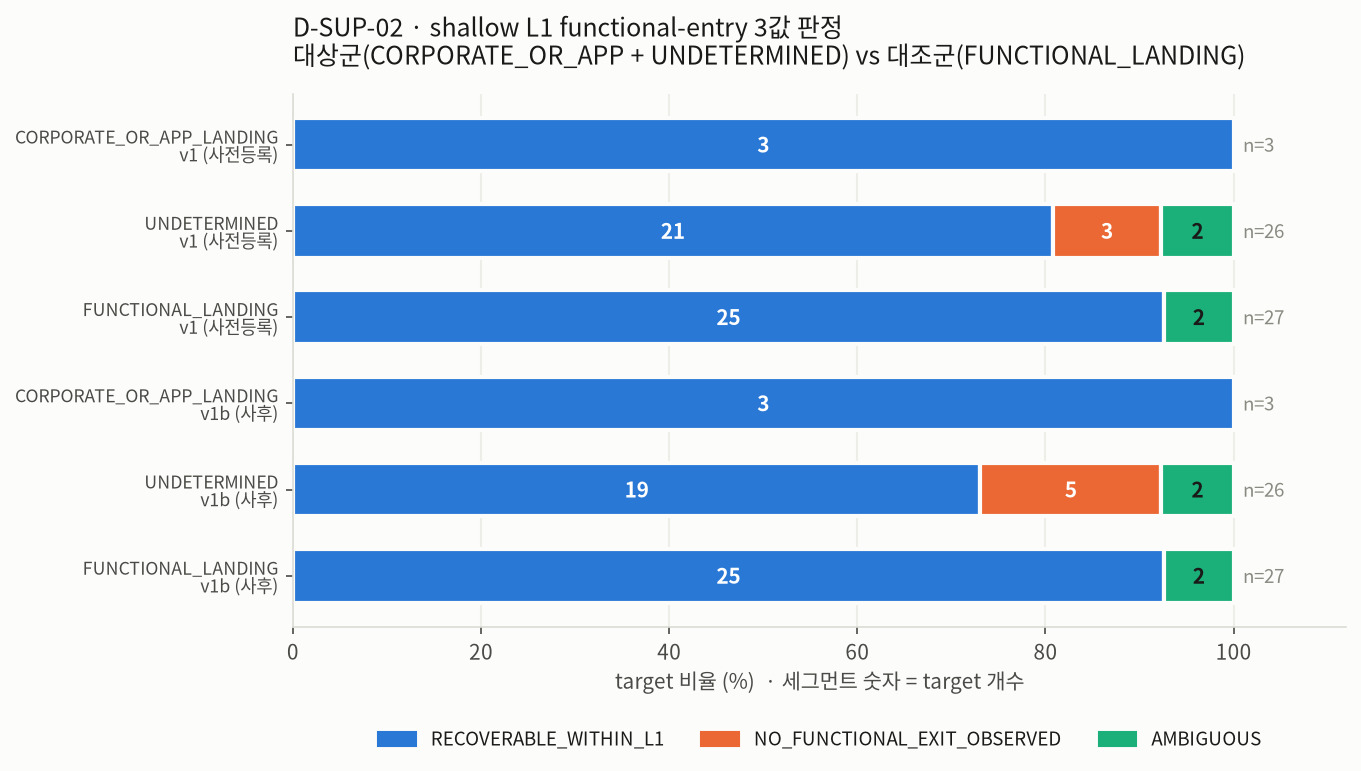

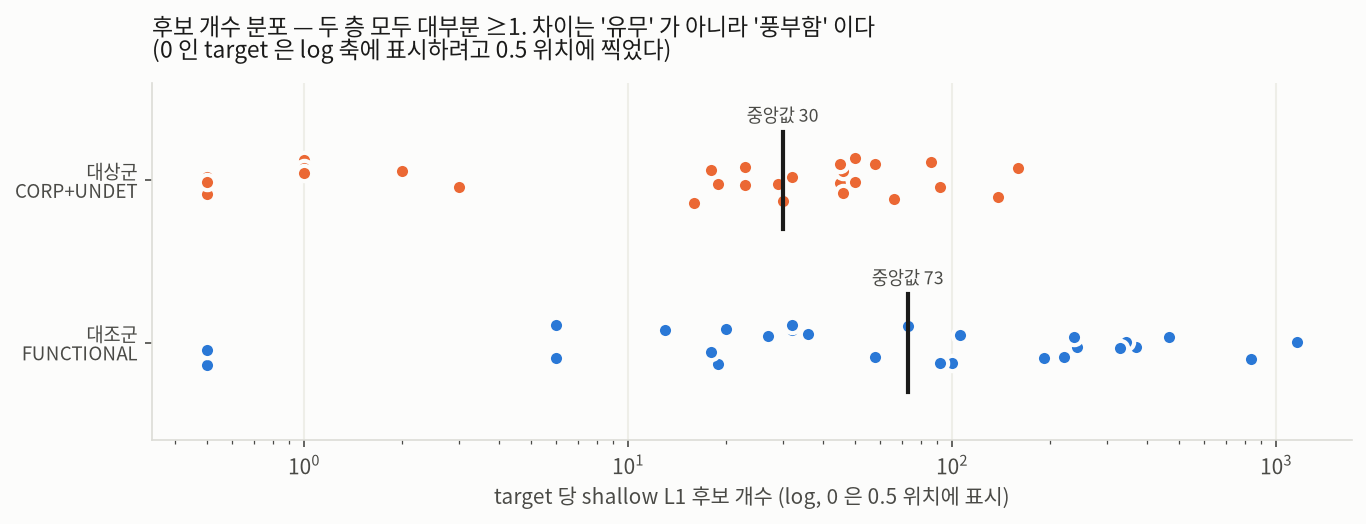

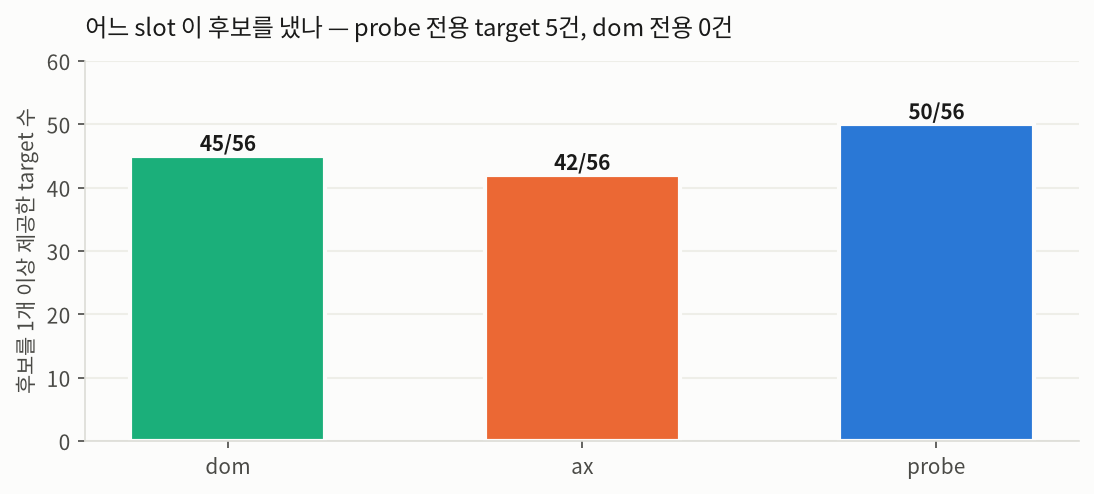

In [16]:
from IPython.display import Image, display
for f in ("DSUP02_verdict_by_stratum.png", "DSUP02_candidate_distribution.png",
          "DSUP02_slot_provenance.png"):
    display(Image(filename=str(RD / "figures" / f)))

## 12. 이 inquiry 가 답하지 않는 것 · verdict · limitation

In [17]:
for s in DOC["not_answered_by_this_inquiry"]:
    print(" -", s)
print("\nVERDICT:", DOC["verdict"])
print("BASIS  :", DOC["verdict_basis"])
print("\nLIMITATION:\n" + DOC["limitation"])
print("\nFIREWALL:\n" + DOC["firewall_note"])

 - 후보가 실제로 작동하는지 — 어떤 후보도 클릭하지 않았다 (live navigation 없음).
 - 후보가 어느 archetype 의 Region 인지 — 정하지 않는다. region_class_hits 는 다중 라벨 힌트일 뿐 archetype 판정이 아니다.
 - 대표기능 gold label — 생성하지 않았다.
 - frame 을 고쳐야 하는지 — A 의 권한이다.

VERDICT: SUPPORTED
BASIS  : 대상군에서 shallow L1 후보가 압도적으로 관측됐다. 다만 대조군도 같은 수준이므로 이 지표는 존재 주장만 지지하고 판별력은 없다.

LIMITATION:
후보는 존재 주장이지 도달 주장이 아니다. 어휘 사전은 연구자가 만든 것이고 상한 없는 재현율을 주장하지 않는다. 제외 규칙(특히 E5 고객지원·E9 auth)은 보수적으로 설계돼 후보를 과소계수하는 방향이며, 그래도 대상군이 거의 전부 RECOVERABLE 이면 그 결론은 보수적 방향에서 안전하다. probe primary_action_candidates 는 200개에서 절단(cap)된 target 이 7개 있어 후보 개수의 상단이 censored 다 (≥1 규칙에는 영향 없음). CORPORATE_OR_APP_LANDING stratum 은 n=3 이라 Wilson CI 가 매우 넓다 — 과해석 금지.

FIREWALL:
holdout label · LABEL_SPLIT_FROZEN* · HOLDOUT_FOR_C* · RAW_L1~L4* · PACKET_L* · *_OVERLAP* · PRECEDENCE_CONTESTED* · CALIBRATION_FOR_B* · **/control/** · B/C 의 target-level holdout error report 는 **열지 않았다**. 이 분석은 l0a slot 3개 파일(dom.html/ax.json/probe.json)과 research_d/results 만 읽었다.
